# 01 — Exploratory Data Analysis (EDA)

This notebook explores the **English Web Treebank (UD v2)** dataset used for our rule-based POS tagger.  
We look at:
1. Dataset size (sentences, tokens) across train / dev / test splits
2. POS-tag distribution & frequency
3. Sentence-length distribution
4. Vocabulary statistics (type–token ratio, hapax legomena)
5. Tag-transition heatmap (bigram frequencies)
6. Most frequent words per POS tag

In [1]:
import os, re, warnings
from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)

matplotlib.use("module://matplotlib_inline.backend_inline")


DATA_DIR = Path("../data")

## 1  Parsing the CoNLL-U files

In [2]:
def parse_conllu(filepath):
    """Parse a CoNLL-U file and return a list of sentences.
    Each sentence is a list of dicts with keys:
      id, form, lemma, upos, xpos, feats, head, deprel, deps, misc
    Multi-word tokens (e.g. '6-7') are skipped.
    """
    sentences = []
    current = []
    with open(filepath, encoding="utf-8") as f:
        for line in f:
            line = line.rstrip("\n")
            if line.startswith("#"):
                continue
            if line == "":
                if current:
                    sentences.append(current)
                    current = []
                continue
            fields = line.split("\t")
            if len(fields) != 10:
                continue
            tok_id = fields[0]
            # skip multi-word token lines like '6-7'
            if "-" in tok_id or "." in tok_id:
                continue
            current.append({
                "id": int(tok_id),
                "form": fields[1],
                "lemma": fields[2],
                "upos": fields[3],
                "xpos": fields[4],
                "feats": fields[5],
                "head": fields[6],
                "deprel": fields[7],
                "deps": fields[8],
                "misc": fields[9],
            })
    if current:
        sentences.append(current)
    return sentences


splits = {}
for name in ["train", "dev", "test"]:
    path = DATA_DIR / f"en_ewt-ud-{name}.conllu"
    splits[name] = parse_conllu(path)

print("Parsing complete ✓")

Parsing complete ✓


## 2  High-level statistics

In [3]:
rows = []
for split, sents in splits.items():
    n_tokens = sum(len(s) for s in sents)
    vocab = set(tok["form"] for s in sents for tok in s)
    rows.append({
        "Split": split,
        "Sentences": len(sents),
        "Tokens": n_tokens,
        "Types (vocab)": len(vocab),
        "Avg sent len": round(n_tokens / len(sents), 1),
    })

summary_df = pd.DataFrame(rows)
summary_df

,Split,Sentences,Tokens,Types (vocab),Avg sent len
0,train,12544,204577,19674,16.3
1,dev,2001,25147,5494,12.6
2,test,2077,25094,5629,12.1


## 3  UPOS tag distribution

In [4]:
# Aggregate across all splits for the overall view
all_tags = [tok["upos"] for sents in splits.values() for s in sents for tok in s]
tag_counts = Counter(all_tags)
tag_df = (
    pd.DataFrame(tag_counts.items(), columns=["UPOS", "Count"])
    .sort_values("Count", ascending=False)
    .reset_index(drop=True)
)
tag_df["Pct"] = (tag_df["Count"] / tag_df["Count"].sum() * 100).round(2)
tag_df

,UPOS,Count,Pct
0,NOUN,43084,16.91
1,PUNCT,29767,11.68
2,VERB,27888,10.94
3,PRON,23066,9.05
4,ADP,21777,8.55
5,DET,20096,7.89
6,ADJ,16789,6.59
7,PROPN,16562,6.50
8,AUX,15925,6.25
9,ADV,12595,4.94


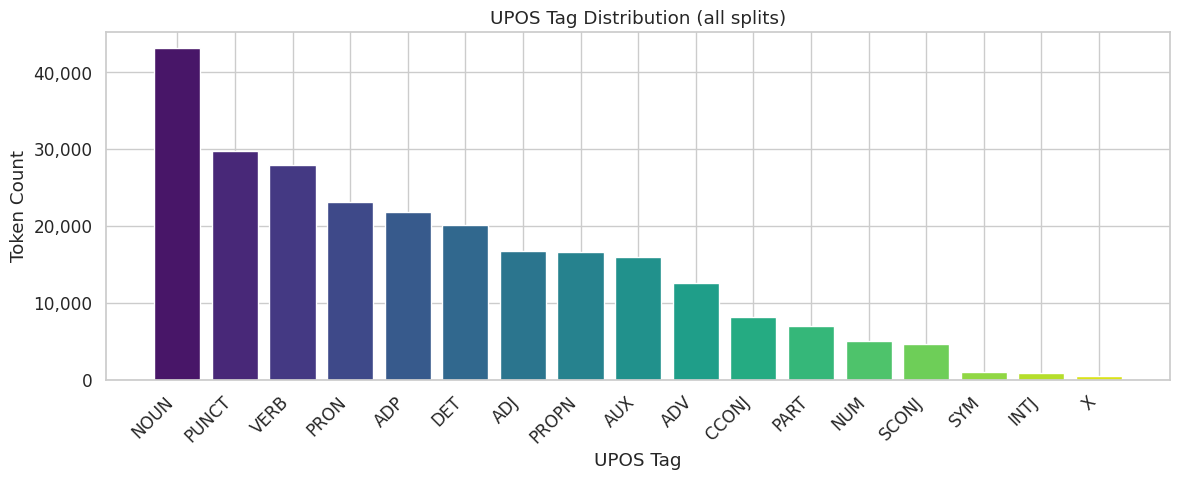

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
colors = sns.color_palette("viridis", n_colors=len(tag_df))
ax.bar(tag_df["UPOS"], tag_df["Count"], color=colors)
ax.set_xlabel("UPOS Tag")
ax.set_ylabel("Token Count")
ax.set_title("UPOS Tag Distribution (all splits)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../outputs/UPOS_Tag_Distribution.png",dpi=150)
plt.show()

## 4  UPOS distribution per split (normalised)

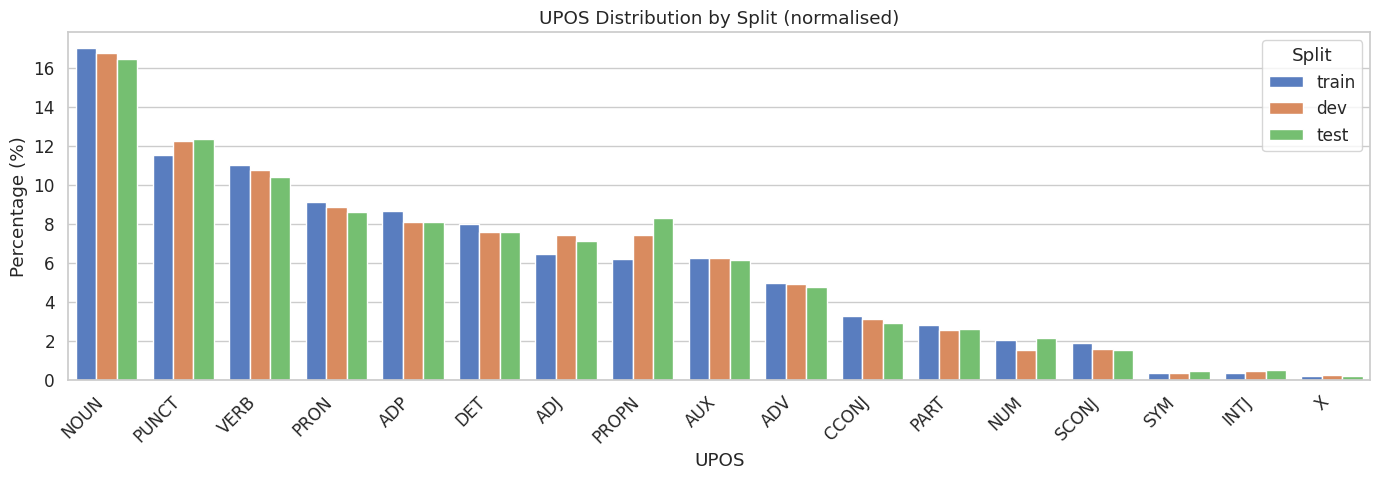

In [ ]:
split_tag_data = []
for split, sents in splits.items():
    tags = [tok["upos"] for s in sents for tok in s]
    total = len(tags)
    for tag, cnt in Counter(tags).items():
        split_tag_data.append({"Split": split, "UPOS": tag, "Pct": cnt / total * 100})

split_tag_df = pd.DataFrame(split_tag_data)

fig, ax = plt.subplots(figsize=(14, 5))
sns.barplot(data=split_tag_df, x="UPOS", y="Pct", hue="Split",
            order=tag_df["UPOS"], ax=ax)
ax.set_ylabel("Percentage (%)")
ax.set_title("UPOS Distribution by Split (normalised)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../outputs/UPOS_Tag_Distribution_by_split.png",dpi=150)
plt.show()

## 5  Sentence-length distribution

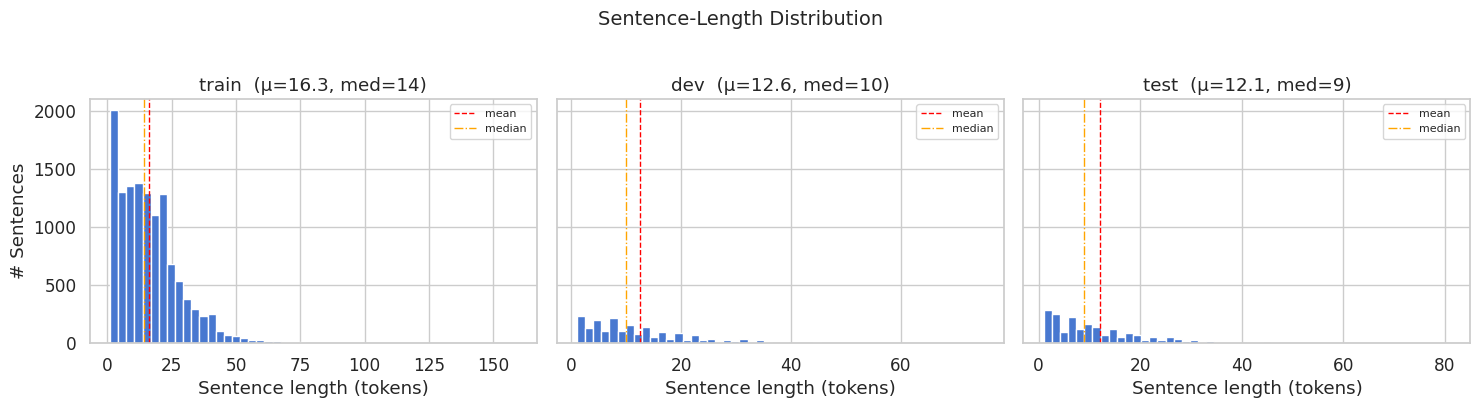

In [ ]:
sent_lens = {split: [len(s) for s in sents] for split, sents in splits.items()}

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, (split, lens) in zip(axes, sent_lens.items()):
    ax.hist(lens, bins=50, color=sns.color_palette("muted")[0], edgecolor="white")
    ax.set_title(f"{split}  (μ={np.mean(lens):.1f}, med={np.median(lens):.0f})")
    ax.set_xlabel("Sentence length (tokens)")
    ax.axvline(np.mean(lens), color="red", ls="--", lw=1, label="mean")
    ax.axvline(np.median(lens), color="orange", ls="-.", lw=1, label="median")
    ax.legend(fontsize=8)
axes[0].set_ylabel("# Sentences")
fig.suptitle("Sentence-Length Distribution", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("../outputs/Sentence_Length_Distribution.png",dpi=150)
plt.show()

## 6  Vocabulary & lexical diversity

In [8]:
for split, sents in splits.items():
    forms = [tok["form"] for s in sents for tok in s]
    vocab = Counter(forms)
    hapax = sum(1 for w, c in vocab.items() if c == 1)
    ttr = len(vocab) / len(forms)
    print(f"[{split:5s}]  types={len(vocab):,}  tokens={len(forms):,}  "
          f"TTR={ttr:.4f}  hapax={hapax:,} ({hapax/len(vocab)*100:.1f}% of vocab)")

[train]  types=19,674  tokens=204,577  TTR=0.0962  hapax=9,801 (49.8% of vocab)
[dev  ]  types=5,494  tokens=25,147  TTR=0.2185  hapax=3,328 (60.6% of vocab)
[test ]  types=5,629  tokens=25,094  TTR=0.2243  hapax=3,483 (61.9% of vocab)


## 7  Top-10 most frequent words per POS tag (train)

In [9]:
train_tokens = [(tok["form"], tok["upos"]) for s in splits["train"] for tok in s]
tag_word_freq = defaultdict(Counter)
for form, upos in train_tokens:
    tag_word_freq[upos][form] += 1

top_words = {}
for tag in tag_df["UPOS"]:
    top_words[tag] = tag_word_freq[tag].most_common(10)

# Display as a compact table
rows = []
for tag, words in top_words.items():
    words_str = ", ".join(f"{w} ({c})" for w, c in words)
    rows.append({"UPOS": tag, "Top-10 words (count)": words_str})

pd.set_option("display.max_colwidth", 120)
pd.DataFrame(rows)

,UPOS,Top-10 words (count)
0,NOUN,"time (384), people (233), way (186), place (178), year (168), day (163), Thanks (159), food (157), service (157), ye..."
1,PUNCT,". (8640), , (7019), - (1313), "" (1292), ) (882), ( (848), ? (764), : (593), ! (529), ... (227)"
2,VERB,"have (745), get (359), know (338), had (324), go (258), do (257), said (233), want (209), going (190), see (189)"
3,PRON,"I (3122), you (1920), it (1467), they (832), that (787), my (761), your (632), he (630), we (613), me (588)"
4,ADP,"of (3456), in (2708), to (1785), for (1648), on (1100), with (1097), at (735), from (602), by (534), as (361)"
5,DET,"the (8141), a (3589), The (884), this (599), an (473), all (404), some (324), any (289), no (200), that (160)"
6,ADJ,"other (268), good (251), new (195), more (164), many (160), great (159), best (134), same (132), sure (111), last (107)"
7,PROPN,"Bush (211), US (162), Iraq (119), Enron (95), Iran (83), China (79), Al (78), States (70), India (64), John (63)"
8,AUX,"is (2048), was (1188), be (1091), are (992), will (811), would (578), can (578), have (573), do (471), were (361)"
9,ADV,"so (371), just (353), when (307), very (298), also (282), only (203), even (202), there (198), now (195), then (188)"


## 8  POS-tag bigram transition heatmap (train)

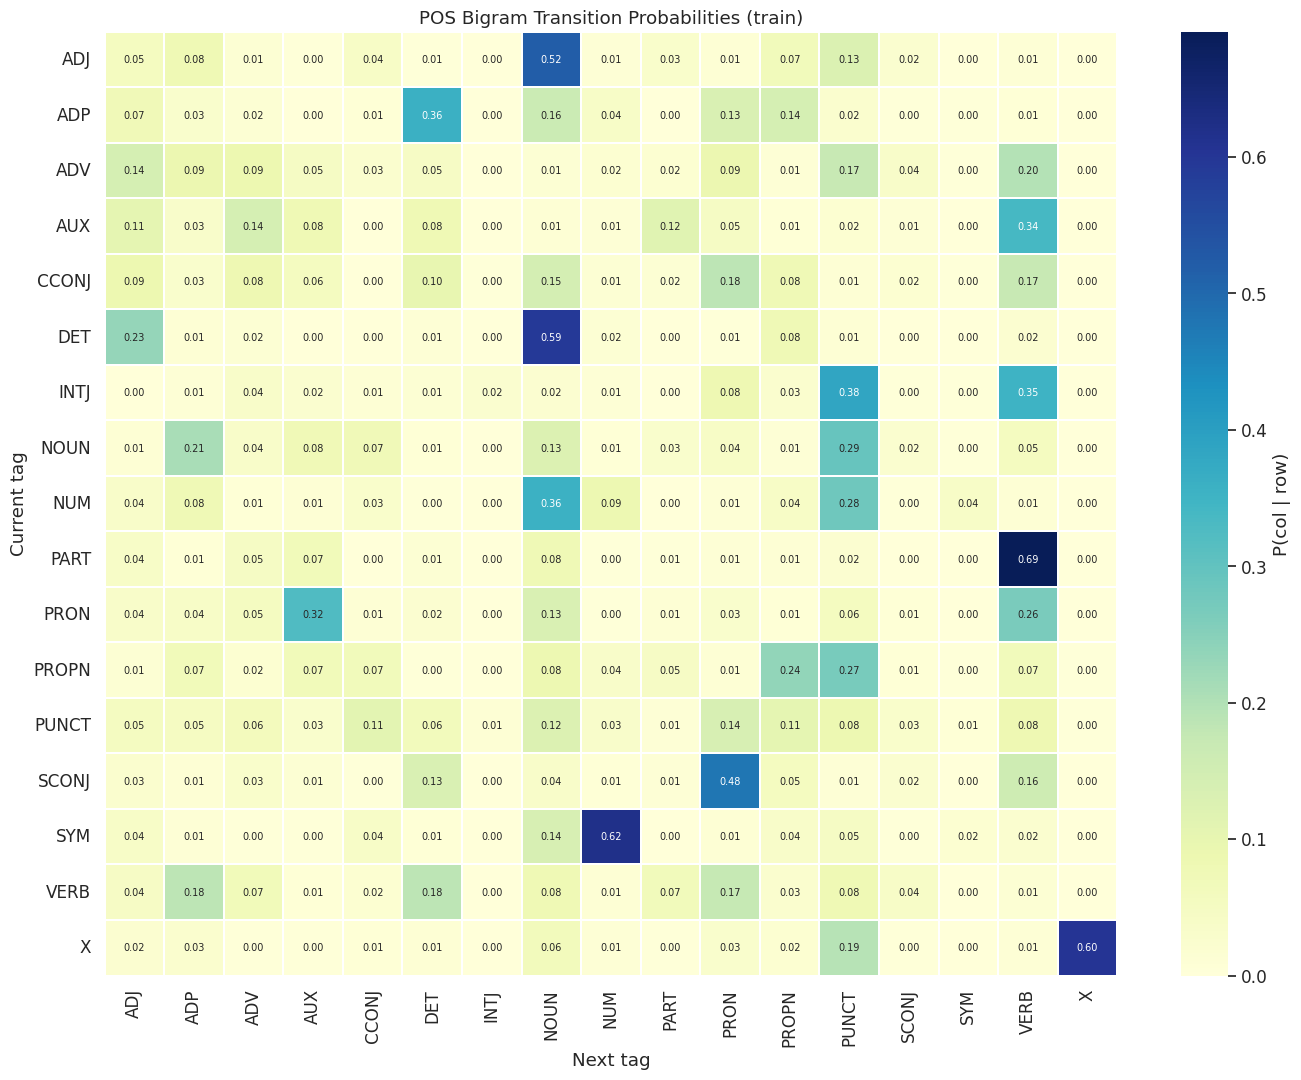

In [ ]:
bigram_counts = Counter()
for sent in splits["train"]:
    tags = [tok["upos"] for tok in sent]
    for t1, t2 in zip(tags, tags[1:]):
        bigram_counts[(t1, t2)] += 1

all_upos = sorted(tag_counts.keys())
bigram_matrix = pd.DataFrame(0, index=all_upos, columns=all_upos)
for (t1, t2), cnt in bigram_counts.items():
    bigram_matrix.loc[t1, t2] = cnt

# Normalise rows to get P(tag_i+1 | tag_i)
bigram_probs = bigram_matrix.div(bigram_matrix.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(bigram_probs, annot=True, fmt=".2f", cmap="YlGnBu",
            linewidths=0.3, ax=ax, cbar_kws={"label": "P(col | row)"},
            annot_kws={"size": 7})
ax.set_xlabel("Next tag")
ax.set_ylabel("Current tag")
ax.set_title("POS Bigram Transition Probabilities (train)")
plt.tight_layout()
plt.savefig("../outputs/POS_Bigram_transition_probabilities_train.png",dpi=150)
plt.show()

## 9  Ambiguity: words with multiple POS tags

In [11]:
word_tags = defaultdict(set)
word_freq = Counter()
for s in splits["train"]:
    for tok in s:
        w = tok["form"].lower()
        word_tags[w].add(tok["upos"])
        word_freq[w] += 1

ambig = {w: tags for w, tags in word_tags.items() if len(tags) > 1}
print(f"Total word types (lowercased): {len(word_tags):,}")
print(f"Ambiguous types (>1 UPOS):     {len(ambig):,}  "
      f"({len(ambig)/len(word_tags)*100:.1f}%)")

# Show most frequent ambiguous words
ambig_sorted = sorted(ambig.items(), key=lambda x: -word_freq[x[0]])[:20]
ambig_df = pd.DataFrame([
    {"Word": w, "Freq": word_freq[w], "Tags": ", ".join(sorted(tags))}
    for w, tags in ambig_sorted
])
ambig_df

Total word types (lowercased): 16,654
Ambiguous types (>1 UPOS):     2,116  (12.7%)


,Word,Freq,Tags
0,the,9075,"ADP, DET, PART, PRON"
1,",",7021,"PUNCT, X"
2,to,5137,"ADP, ADV, DET, NOUN, PART, SCONJ, VERB, X"
3,and,5002,"ADP, CCONJ, DET, X"
4,a,3782,"ADP, ADV, AUX, CCONJ, DET, NOUN, NUM, PART, PROPN, SYM, X"
5,of,3622,"ADP, ADV, AUX, CCONJ, SCONJ"
6,i,3380,"NUM, PRON, PROPN"
7,in,3112,"ADJ, ADP, ADV, AUX, NOUN, SCONJ, X"
8,is,2239,"AUX, PRON, VERB"
9,you,2156,"NOUN, PRON, PROPN"


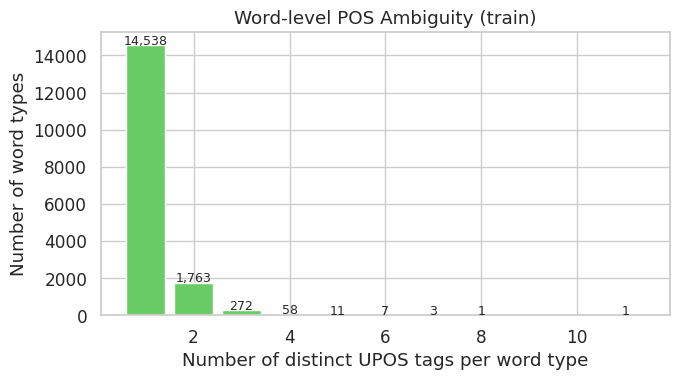

In [ ]:
# Distribution of ambiguity levels
ambig_levels = Counter(len(tags) for tags in word_tags.values())
ambig_level_df = pd.DataFrame(
    sorted(ambig_levels.items()), columns=["# POS tags", "# Word types"]
)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(ambig_level_df["# POS tags"], ambig_level_df["# Word types"],
       color=sns.color_palette("muted")[2], edgecolor="white")
ax.set_xlabel("Number of distinct UPOS tags per word type")
ax.set_ylabel("Number of word types")
ax.set_title("Word-level POS Ambiguity (train)")
for i, row in ambig_level_df.iterrows():
    ax.text(row["# POS tags"], row["# Word types"] + 50,
            f"{row['# Word types']:,}", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("../outputs/Word_level_pos_ambiguity_train.png",dpi=150)
plt.show()

## 10  Key takeaways

- **NOUN**, **PUNCT**, **VERB**, and **ADP** are the most frequent tags — together they account for ~50 % of all tokens.  
- Sentence lengths are right-skewed; most sentences have 10 – 25 tokens.  
- **~15–20 %** of word types are ambiguous (appear with more than one POS tag), which is the main challenge a rule-based tagger must handle.  
- The tag bigram heatmap reveals strong patterns (e.g. DET → NOUN, ADP → NOUN/PROPN) that contextual rules can exploit.